In [ ]:
# -*- coding: utf-8 -*-
from odbAccess import openOdb
from abaqusConstants import ELEMENT_NODAL
import numpy as np
import csv
import os

# --- Settings ---
odb_path = r'..\..\1.0-First delta flume\Job-amptest-1200.odb'
output_csv = 'max_principal_stress_per_block2.csv'

# --- Open ODB ---
if not os.path.exists(odb_path):
    raise IOError("ODB file not found: {}".format(odb_path))

odb = openOdb(odb_path)
step = odb.steps[odb.steps.keys()[-1]]  # Use the last step
frames = step.frames
all_instances = odb.rootAssembly.instances

# --- Filter all block instances (names start with "BLOCK") ---
block_names = [name for name in all_instances.keys() if name.startswith('BLOCK')]
block_names.sort()  # Optional: sort alphabetically

# --- Prepare output table ---
header = ['Time'] + block_names
rows = []

for frame_idx, frame in enumerate(frames):
    time = round(frame.frameValue, 2)
    print("time step: {:.4f}".format(time))
    stress_field = frame.fieldOutputs['S']
    row = [time]

    for block_name in block_names:
        print("Processing block:", block_name)
        instance = all_instances[block_name]
        stress_subset = stress_field.getSubset(region=instance, position=ELEMENT_NODAL)

        max_princ = -1e20
        for val in stress_subset.values:
            s = val.data
            stress_tensor = np.array([
                [s[0], s[3], s[4]],
                [s[3], s[1], s[5]],
                [s[4], s[5], s[2]]
            ])
            principal_stresses = np.linalg.eigvalsh(stress_tensor)
            max_p = max(principal_stresses)
            if max_p > max_princ:
                max_princ = max_p

        row.append(max_princ if max_princ > -1e10 else '')

    rows.append(row)

odb.close()

# --- Write to CSV ---
with open(output_csv, 'w') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print("\n✅ Done. Max principal stress per block saved to '{}'".format(output_csv))


✅ Saved: block_grid_halfblock_225mm.png


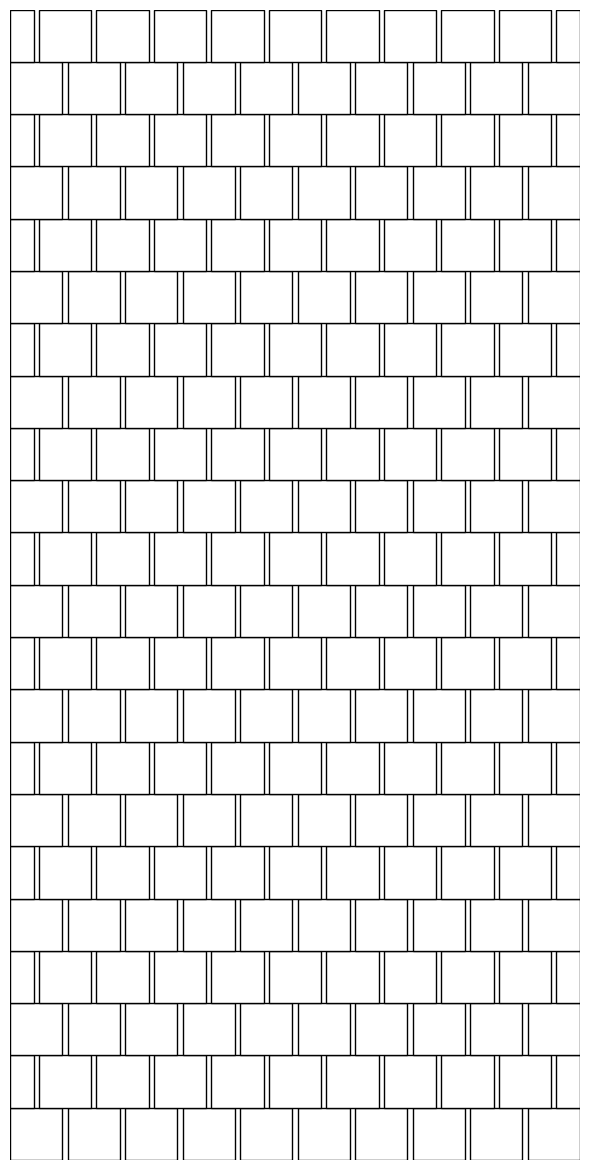

In [1]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Block properties ---
full_w, full_h = 0.5, 0.5       # full block size
half_w, half_h = 0.225, 0.5     # rotated half block: 0.225m wide, 0.5m high
horizontal_spacing = 0.05
vertical_spacing = 0.0
rows = 22

# --- Start figure ---
fig, ax = plt.subplots(figsize=(6, 12))
current_y = 0  # y-position of bottom of current row

for row in range(rows):
    if row % 2 == 0:
        # Even row: 10 full blocks
        for i in range(10):
            x = i * (full_w + horizontal_spacing)
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor='white')
            ax.add_patch(rect)
    else:
        # Odd row: half + 9 full + half
        x = 0
        # First half block
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor='white')
        ax.add_patch(rect)
        x += half_w + horizontal_spacing
        # 9 full blocks
        for i in range(9):
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor='white')
            ax.add_patch(rect)
            x += full_w + horizontal_spacing
        # Final half block
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor='white')
        ax.add_patch(rect)

    # Move up to next row
    current_y += full_h + vertical_spacing

# --- Configure plot ---
ax.set_aspect('equal')
ax.set_xlim(0, x + half_w)  # extend to cover last half block
ax.set_ylim(0, current_y)
ax.axis('off')

plt.tight_layout()
plt.savefig("block_grid_halfblock_225mm.png")
print("✅ Saved: block_grid_halfblock_225mm.png")


✅ Saved: stress_blocks_t6.03s.png


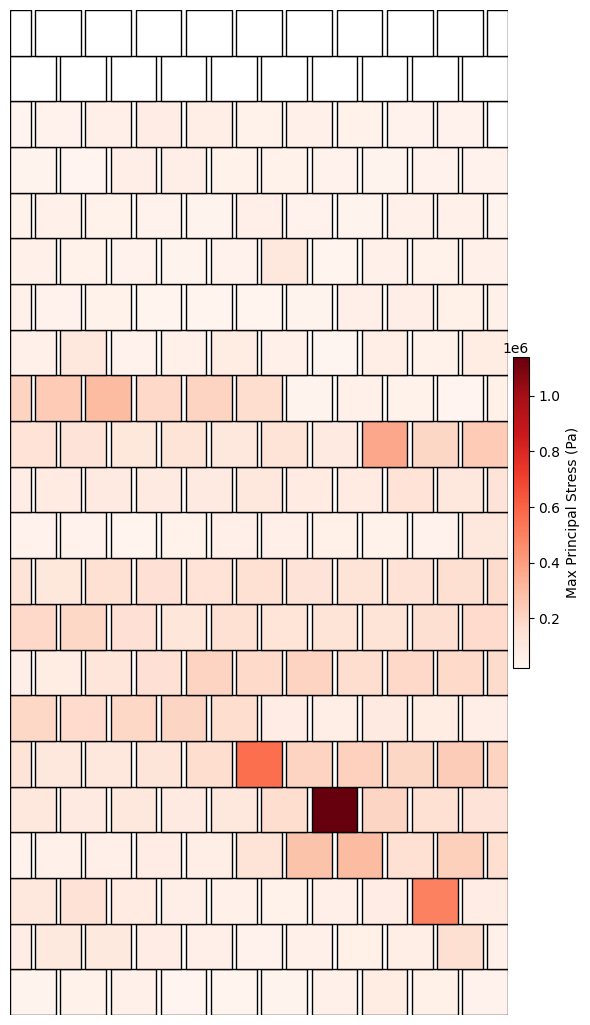

In [8]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import matplotlib.colors as mcolors
import numpy as np

# --- Settings ---
csv_path = 'max_principal_stress_per_block2.csv'
target_time = 6.03  # Time (s) to visualize

# --- Load CSV and get data for time step ---
df = pd.read_csv(csv_path)
df['Time'] = df['Time'].round(2)  # Round time for matching
row = df[df['Time'] == round(target_time, 2)]

if row.empty:
    raise ValueError("⛔ Time step {:.2f} not found in CSV.".format(target_time))

block_data = row.drop(columns='Time').iloc[0]
block_names = block_data.index.tolist()
block_values = block_data.values.astype(float)

# --- Normalize colors ---
norm = mcolors.Normalize(vmin=np.nanmin(block_values), vmax=np.nanmax(block_values))
cmap = plt.cm.Reds

# --- Block layout settings ---
full_w, full_h = 0.5, 0.5
half_w, half_h = 0.225, 0.5
h_spacing = 0.05
v_spacing = 0.0
rows = 22

# --- Initialize plot ---
fig, ax = plt.subplots(figsize=(6, 12))
current_y = 0
block_index = 0

for row_num in range(rows):
    if row_num % 2 == 0:
        # Even rows: 10 full blocks
        for i in range(10):
            x = i * (full_w + h_spacing)
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
    else:
        x = 0
        # First half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1
        x += half_w + h_spacing
        # 9 full blocks
        for i in range(9):
            color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
            rect = patches.Rectangle((x, current_y), full_w, full_h, edgecolor='black', facecolor=color)
            ax.add_patch(rect)
            block_index += 1
            x += full_w + h_spacing
        # Final half block
        color = cmap(norm(block_values[block_index])) if block_index < len(block_values) else 'white'
        rect = patches.Rectangle((x, current_y), half_w, half_h, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        block_index += 1

    current_y += full_h + v_spacing

# --- Format figure ---
ax.set_aspect('equal')
ax.set_xlim(0, x + half_w)
ax.set_ylim(0, current_y)
ax.axis('off')

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Max Principal Stress (Pa)')

# --- Save figure ---
plt.tight_layout()
out_name = f"stress_blocks_t{target_time:.2f}s.png"
plt.savefig(out_name, dpi=300)
print("✅ Saved:", out_name)
